# 06 — Subespaço Gerado (Span)
**Referência:** Boldrini et al., Seção 4.4, p. 112–114

---

## 6.1 Definição (Boldrini, p. 112)

O **subespaço gerado** por $v_1, \ldots, v_n \in V$ é o conjunto de **todas** as combinações lineares possíveis:

$$[v_1, \ldots, v_n] = \{\alpha_1 v_1 + \cdots + \alpha_n v_n \mid \alpha_i \in \mathbb{R}\}$$

Também escrito como $\text{span}\{v_1, \ldots, v_n\}$.

É o **menor subespaço** de $V$ que contém todos os $v_i$.

---

## 6.2 Geometria do Span

| Vetores | Span em $\mathbb{R}^3$ |
|---------|------------------------|
| 1 vetor não nulo | Reta pela origem |
| 2 vetores LI | Plano pela origem |
| 3 vetores LI | Todo $\mathbb{R}^3$ |

---

## 6.3 Vetores Redundantes

Se $v_k$ é CL dos outros, então:
$$[v_1, \ldots, v_k, \ldots, v_n] = [v_1, \ldots, \hat{v}_k, \ldots, v_n]$$

Adicionar um vetor dependente **não amplia** o span — ele é redundante.


In [4]:
from sympy import Matrix, symbols, linsolve, pprint
from sympy import init_printing
init_printing(use_unicode=True)

# ── Verificar se w pertence ao span ──────────────────
def pertence_ao_span(vetores, w):
    '''Verifica se w pertence ao span dos vetores. Vetores: lista de listas.'''
    M = Matrix(vetores).T  # colunas = vetores
    n = len(vetores)
    syms = symbols(f'a:{n}')
    amp = M.row_join(Matrix(w))
    return M.rank() == amp.rank()

# Exemplo 1: span de v=(1,2,3) em R³
print("span{(1,2,3)} — reta na direção (1,2,3)")
print(f"  (2,4,6) ∈ span?    {pertence_ao_span([[1,2,3]], [2,4,6])}")
print(f"  (1,0,0) ∈ span?    {pertence_ao_span([[1,2,3]], [1,0,0])}")

# Exemplo 2: span{e1, e2} = plano xy
print("\nspan{(1,0,0),(0,1,0)} = plano xy")
print(f"  (3,5,0) ∈ span?    {pertence_ao_span([[1,0,0],[0,1,0]], [3,5,0])}")
print(f"  (0,0,1) ∈ span?    {pertence_ao_span([[1,0,0],[0,1,0]], [0,0,1])}")


span{(1,2,3)} — reta na direção (1,2,3)
  (2,4,6) ∈ span?    True
  (1,0,0) ∈ span?    False

span{(1,0,0),(0,1,0)} = plano xy
  (3,5,0) ∈ span?    True
  (0,0,1) ∈ span?    False


In [5]:
# ── Redundância ───────────────────────────────────────
print("Exemplo: v1=(1,0), v2=(0,1), v3=(1,1)")
print("v3 = v1 + v2 → v3 é redundante")
print()

v1 = Matrix([1,0]); v2 = Matrix([0,1]); v3 = Matrix([1,1])

# span{v1,v2,v3} vs span{v1,v2}
M12  = v1.row_join(v2)
M123 = v1.row_join(v2).row_join(v3)

print(f"posto span{{v1,v2}}    = {M12.rank()}")
print(f"posto span{{v1,v2,v3}} = {M123.rank()}")
print(f"Mesmo posto → span{{v1,v2,v3}} = span{{v1,v2}}  ✓")


Exemplo: v1=(1,0), v2=(0,1), v3=(1,1)
v3 = v1 + v2 → v3 é redundante

posto span{v1,v2}    = 2
posto span{v1,v2,v3} = 2
Mesmo posto → span{v1,v2,v3} = span{v1,v2}  ✓


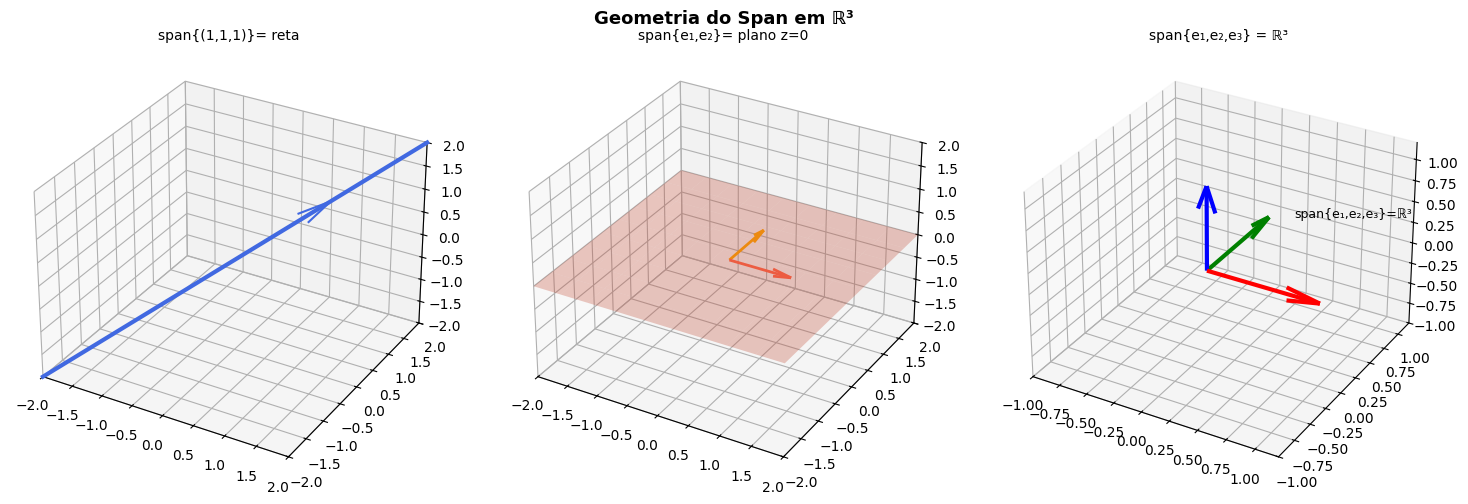

In [6]:
# ── Visualização ─────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(15, 5))

# --- 1 vetor → reta ---
ax1 = fig.add_subplot(131, projection='3d')
t = np.linspace(-2, 2, 50)
v = np.array([1, 1, 1])
ax1.plot(t*v[0], t*v[1], t*v[2], 'royalblue', lw=3)
ax1.quiver(0,0,0, *v, color='royalblue', arrow_length_ratio=0.3)
ax1.set_title('span{(1,1,1)}= reta', fontsize=10)
ax1.set_xlim(-2,2); ax1.set_ylim(-2,2); ax1.set_zlim(-2,2)

# --- 2 vetores → plano ---
ax2 = fig.add_subplot(132, projection='3d')
xx, yy = np.meshgrid(np.linspace(-2, 2, 10), np.linspace(-2, 2, 10))
zz = np.zeros_like(xx)
ax2.plot_surface(xx, yy, zz, alpha=0.3, color='tomato')
ax2.quiver(0,0,0, 1,0,0, color='tomato', arrow_length_ratio=0.3, lw=2)
ax2.quiver(0,0,0, 0,1,0, color='orange', arrow_length_ratio=0.3, lw=2)
ax2.set_title('span{e₁,e₂}= plano z=0', fontsize=10)
ax2.set_xlim(-2,2); ax2.set_ylim(-2,2); ax2.set_zlim(-2,2)

# --- 3 vetores LI → R³ ---
ax3 = fig.add_subplot(133, projection='3d')
for v_dir, color in [([1,0,0],'red'), ([0,1,0],'green'), ([0,0,1],'blue')]:
    ax3.quiver(0,0,0, *v_dir, color=color, arrow_length_ratio=0.3, lw=3)
ax3.text(0.5, 0.5, 0.5, 'span{e₁,e₂,e₃}=ℝ³', fontsize=9, color='black')
ax3.set_title('span{e₁,e₂,e₃} = ℝ³', fontsize=10)
ax3.set_xlim(-1,1.2); ax3.set_ylim(-1,1.2); ax3.set_zlim(-1,1.2)

plt.suptitle('Geometria do Span em ℝ³', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
